# **Generate SNA**

### **README**
1. Majority of the cells is based off the course notebook (`.ipynb`)
2. A **task / pipeline summary** is written on the latter part of the notebook. Please scroll for easy read through of the process!

In [1]:
# Optional: Uncomment to install
%pip install networkx matplotlib numpy pandas # vaderSentiment
%pip install stopwordsiso

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import urllib.request
import zipfile
import io
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import networkx as nx

np.random.seed(42)
print('networkx:', nx.__version__)
print('numpy:', np.__version__)
print('pandas:', pd.__version__)


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


networkx: 3.5
numpy: 1.26.4
pandas: 2.3.2


In [2]:
import pandas as pd

# Load your raw Reddit data
df = pd.read_csv("reddit_data.csv")

comments_df = df[['comment','comment_author','comment_score','created_utc']]

# Keep only comment rows
comments_df = df[df["comment"].notna()].copy()

# Fill missing comment authors (preserve deleted users)
comments_df["comment_author"] = comments_df["comment_author"].fillna("[deleted]")

# Remove empty comments ("" or just spaces)
comments_df = comments_df[comments_df["comment"].str.strip() != ""]

# Normalize text (remove weird spacing, lowercasing optional)
comments_df["comment"] = comments_df["comment"].astype(str).str.strip()

# Optional: lowercase text if you plan to tokenize or sentiment analyze
comments_df["comment"] = comments_df["comment"].str.lower()

# Drop exact duplicates
comments_df = comments_df.drop_duplicates(subset=["comment_author", "comment"])

# Reset index
comments_df = comments_df.reset_index(drop=True)


In [3]:
comments_df.to_csv("reddit_agriculture_comments_clean.csv", index=False)


In [4]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"&amp;", "and", text)  # replace HTML entities
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # remove special characters
    return text.strip()

comments_df["clean_comment"] = comments_df["comment"].apply(clean_text)

comments_df.tail()


,post_title,post_url,comment,comment_author,comment_score,post_body,post_score,post_author,created_utc,clean_comment
12547,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,that’s why fuck the dutertes,nikolodeon,10.0,NaN,NaN,NaN,2024-05-03 11:30:11,thats why fuck the dutertes
12548,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,fr? that's scary.,[deleted],2.0,NaN,NaN,NaN,2024-05-03 12:32:41,fr thats scary
12549,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,this partnership is very daijoubu,IkigaiSagasu,5.0,NaN,NaN,NaN,2024-05-03 10:33:52,this partnership is very daijoubu
12550,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,"yeah, there’s a huge connection between corrup...",FilipinxFurry,1.0,NaN,NaN,NaN,2024-05-03 12:36:12,yeah theres a huge connection between corrupt ...
12551,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,"yup ganyan din ginagawa ng russia, kaya mas pi...",SuperBombaBoy,1.0,NaN,NaN,NaN,2024-05-03 16:57:35,yup ganyan din ginagawa ng russia kaya mas pin...


In [5]:
import stopwordsiso as stopwords

filipino_stopwords = stopwords.stopwords("tl") 
english_stopwords = stopwords.stopwords("en") 
combined_stopwords = list(filipino_stopwords.union(english_stopwords))
print("Total stopwords:", len(combined_stopwords))



Total stopwords: 1436


f:\_GitHub\CSCI161-SocialComputing\venv\Lib\site-packages\stopwordsiso\_core.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words=combined_stopwords,
    max_features=1000,
    lowercase=True,
    ngram_range=(1, 1)
)

tfidf_matrix = vectorizer.fit_transform(comments_df['comment'].astype(str))
feature_names = vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", tfidf_matrix.shape)


f:\_GitHub\CSCI161-SocialComputing\venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ain', 'daren', 'hadn', 'herse', 'himse', 'itse', 'mayn', 'mightn', 'mon', 'mustn', 'myse', 'needn', 'oughtn', 'shan'] not in stop_words.
  warnings.warn(


TF-IDF matrix shape: (12552, 1000)


In [7]:
num_comments = tfidf_matrix.shape[0]
comment_nodes = [f"comment_{i}" for i in range(num_comments)]

In [8]:
cosine_sim_matrix = linear_kernel(tfidf_matrix, tfidf_matrix)

comment_edges = []
similarity_threshold = 0.5 

for i in range(num_comments):
    for j in range(i + 1, num_comments): 
        if cosine_sim_matrix[i, j] > similarity_threshold:
            comment_edges.append((comment_nodes[i], comment_nodes[j]))

print(f"Total edges (similarity > {similarity_threshold}):", len(comment_edges))

Total edges (similarity > 0.5): 60374


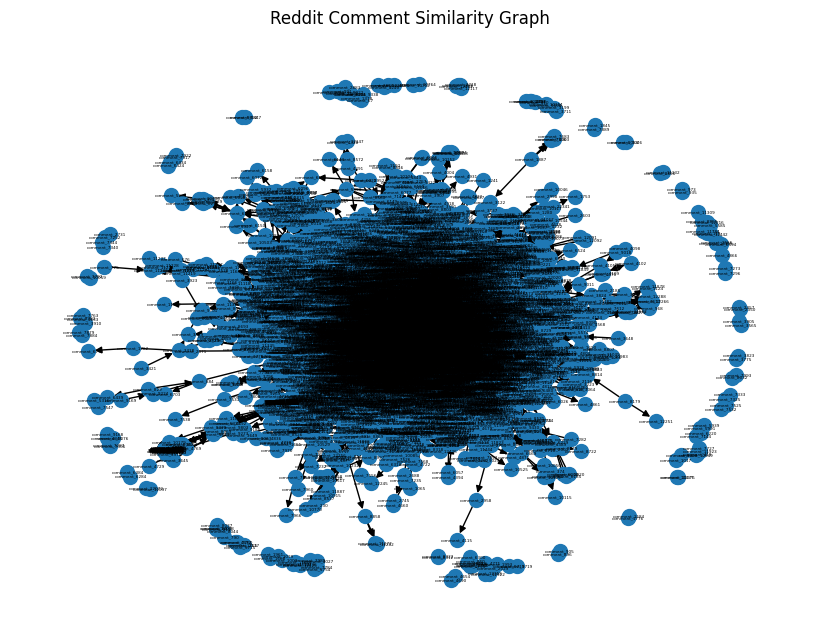

Nodes: 8883 | Edges: 60374


In [9]:
G = nx.DiGraph()
G.add_edges_from(comment_edges)

# Layout and draw
pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(8,6))
nx.draw(G, pos, with_labels=True, node_size=100, font_size=3)
plt.title("Reddit Comment Similarity Graph")
plt.show()

print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")


---

## **Adjacency Representations**

### **Adjacecny Matrix**




In [10]:
nodes = list(G.nodes())
A = nx.to_numpy_array(G, nodelist=nodes, dtype=int)
adj_df = pd.DataFrame(A, index=nodes, columns=nodes)
adj_df

,comment_1,comment_2,comment_3,comment_11,comment_13,comment_14,comment_16,comment_18,comment_23,comment_24,...,comment_12375,comment_12378,comment_12381,comment_12396,comment_12400,comment_12425,comment_12436,comment_12491,comment_12501,comment_12513
comment_1,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
comment_2,0,0,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
comment_3,0,0,0,1,1,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
comment_11,0,0,0,0,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
comment_13,0,0,0,0,0,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
comment_12425,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
comment_12436,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
comment_12491,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
comment_12501,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
adj_list = {n: list(G.neighbors(n)) for n in G.nodes()}
for k in list(adj_list)[:10]:
    print(f"{k}: {adj_list[k]}")



comment_1: ['comment_2', 'comment_3', 'comment_11', 'comment_13', 'comment_14', 'comment_16', 'comment_18', 'comment_23', 'comment_24', 'comment_36', 'comment_37', 'comment_40', 'comment_42', 'comment_43', 'comment_44', 'comment_48', 'comment_52', 'comment_55', 'comment_74', 'comment_5340', 'comment_5710', 'comment_5721', 'comment_5726', 'comment_5742', 'comment_5746', 'comment_5797', 'comment_5806', 'comment_9349', 'comment_9857']
comment_2: ['comment_3', 'comment_11', 'comment_13', 'comment_14', 'comment_18', 'comment_23', 'comment_24', 'comment_36', 'comment_37', 'comment_40', 'comment_43', 'comment_55', 'comment_65', 'comment_5721', 'comment_5742', 'comment_5746', 'comment_5821', 'comment_5892', 'comment_7812']
comment_3: ['comment_11', 'comment_13', 'comment_18', 'comment_23', 'comment_24', 'comment_36', 'comment_40', 'comment_43', 'comment_55', 'comment_5721', 'comment_5742', 'comment_5746', 'comment_5821', 'comment_5892']
comment_11: ['comment_13', 'comment_14', 'comment_18', 'c

In [12]:
# Edge List
edge_list = list(G.edges())

for edge in list(G.edges(data=True))[:10]:
    print(edge) 



('comment_1', 'comment_2', {})
('comment_1', 'comment_3', {})
('comment_1', 'comment_11', {})
('comment_1', 'comment_13', {})
('comment_1', 'comment_14', {})
('comment_1', 'comment_16', {})
('comment_1', 'comment_18', {})
('comment_1', 'comment_23', {})
('comment_1', 'comment_24', {})
('comment_1', 'comment_36', {})


---
## **2. Network Properties**

- Density (for directed graphs: m / (n*(n-1)))
- Degree / in-degree / out-degree
- (Weakly) Connected components (for directed graphs)
- Shortest path distance
- Clustering coefficient


In [13]:
n = G.number_of_nodes()  # n = number of nodes
m = G.number_of_edges()  # m = number of edges
density = m / (n * (n - 1))  # density is the ratio of edges to possible edges
deg_in = dict(G.in_degree())  # in-degree is the number of incoming edges to a node
deg_out = dict(G.out_degree())  # out-degree is the number of outgoing edges from a node
# components is the number of "islands" in the graph or the group of nodes that are connected to each other but not to other nodes in the graph
components = [c for c in nx.weakly_connected_components(G)]

# sample distance is the shortest path from node 'a' to node 'b'
# sample_distance = nx.shortest_path_length(G, source='a', target='b')

clust_coeff = nx.clustering(G.to_undirected())
summary = {
  'n_nodes': n,
  'n_edges': m,
  'density': density,
  'in_degree': deg_in,
  'out_degree': deg_out,
  'n_weak_components': len(components),
  # 'shortest_distance_a_to_b': sample_distance,
}
summary, clust_coeff

({'n_nodes': 8883,
  'n_edges': 60374,
  'density': 0.0007652080311582915,
  'in_degree': {'comment_1': 0,
   'comment_2': 1,
   'comment_3': 2,
   'comment_11': 3,
   'comment_13': 4,
   'comment_14': 4,
   'comment_16': 1,
   'comment_18': 5,
   'comment_23': 10,
   'comment_24': 8,
   'comment_36': 10,
   'comment_37': 10,
   'comment_40': 14,
   'comment_42': 7,
   'comment_43': 13,
   'comment_44': 9,
   'comment_48': 13,
   'comment_52': 3,
   'comment_55': 14,
   'comment_74': 2,
   'comment_5340': 9,
   'comment_5710': 16,
   'comment_5721': 24,
   'comment_5726': 12,
   'comment_5742': 20,
   'comment_5746': 20,
   'comment_5797': 15,
   'comment_5806': 18,
   'comment_9349': 14,
   'comment_9857': 16,
   'comment_65': 11,
   'comment_5821': 16,
   'comment_5892': 14,
   'comment_7812': 16,
   'comment_4': 0,
   'comment_1533': 1,
   'comment_2526': 2,
   'comment_4195': 1,
   'comment_8446': 2,
   'comment_9037': 2,
   'comment_10023': 3,
   'comment_10239': 2,
   'comment_10

## **Centrality Measures**

Compute degree, betweenness, closeness, and eigenvector centrality, then rank top nodes.

In [14]:
deg_cent = nx.degree_centrality(G.to_undirected())
bet_cent = nx.betweenness_centrality(G.to_undirected(), normalized=True)
clo_cent = nx.closeness_centrality(G.to_undirected())
eig_cent = nx.eigenvector_centrality(G.to_undirected(), max_iter=1000)
cent_df = pd.DataFrame({
    'degree': deg_cent,
    'betweenness': bet_cent,
    'closeness': clo_cent,
    'eigenvector': eig_cent,
}).sort_values('degree', ascending=False)
cent_df

,degree,betweenness,closeness,eigenvector
comment_889,0.013961,0.014531,0.236371,9.269344e-02
comment_1478,0.012835,0.002761,0.248357,1.321741e-01
comment_1804,0.012835,0.002761,0.248357,1.321741e-01
comment_11639,0.012835,0.002761,0.248357,1.321741e-01
comment_2449,0.012835,0.002761,0.248357,1.321741e-01
...,...,...,...,...
comment_3837,0.000113,0.000000,0.121444,8.743390e-11
comment_6143,0.000113,0.000000,0.114623,6.304032e-11
comment_3577,0.000113,0.000000,0.137627,6.405393e-09
comment_3569,0.000113,0.000000,0.146619,3.947035e-07


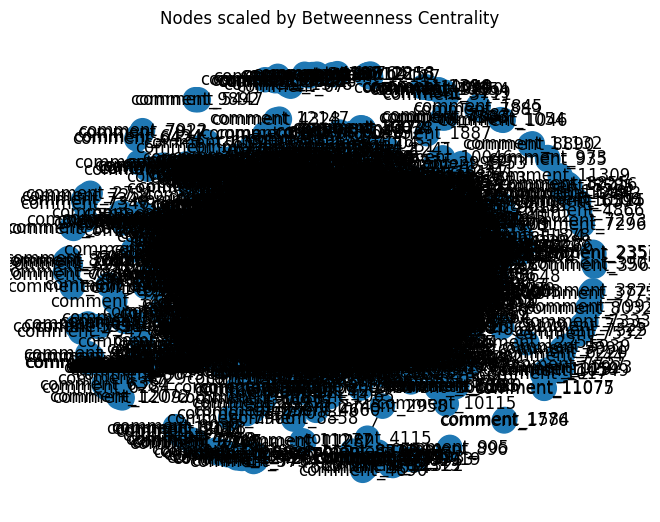

In [15]:
# Visualize with node size scaled by betweenness centrality
plt.figure()
sizes = [3000 * bet_cent[n] + 300 for n in G.nodes()]  # avoid zero size
nx.draw(G.to_undirected(), pos, with_labels=True, node_size=sizes)
plt.title('Nodes scaled by Betweenness Centrality')
plt.show()

### **Example: Zachary's Karate Club (undirected)**
A classic benchmark graph shipped in `networkx`.

In [16]:
K = nx.karate_club_graph()
kpos = nx.spring_layout(K, seed=0)
k_deg = nx.degree_centrality(K)
k_bet = nx.betweenness_centrality(K)
k_clo = nx.closeness_centrality(K)
k_eig = nx.eigenvector_centrality(K, max_iter=1000)
k_df = pd.DataFrame({
    'degree': k_deg,
    'betweenness': k_bet,
    'closeness': k_clo,
    'eigenvector': k_eig,
}).sort_values('degree', ascending=False)
k_df.head(10)

,degree,betweenness,closeness,eigenvector
33,0.515152,0.304075,0.550000,0.373371
0,0.484848,0.437635,0.568966,0.355483
32,0.363636,0.145247,0.515625,0.308651
2,0.303030,0.143657,0.559322,0.317189
1,0.272727,0.053937,0.485294,0.265954
3,0.181818,0.011909,0.464789,0.211174
31,0.181818,0.138276,0.540984,0.191036
23,0.151515,0.017614,0.392857,0.150123
8,0.151515,0.055927,0.515625,0.227405
13,0.151515,0.045863,0.515625,0.226470


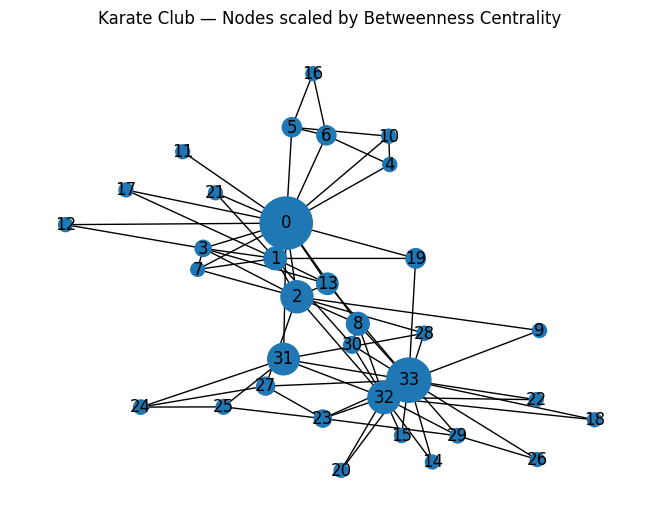

In [17]:
plt.figure()
sizes = [3000 * k_bet[n] + 100 for n in K.nodes()]
nx.draw(K, kpos, with_labels=True, node_size=sizes)
plt.title("Karate Club — Nodes scaled by Betweenness Centrality")
plt.show()

## **Network Models (ER, BA, WS)**
Generate and compare the structural properties of three canonical models.

In [18]:
# ER: Erdős-Rényi, BA: Barabási-Albert, WS: Watts-Strogatz
def model_graphs(n=100, p=0.05, m_attach=2, k=4, beta=0.1):
  ER = nx.erdos_renyi_graph(n, p, seed=1)
  BA = nx.barabasi_albert_graph(n, m_attach, seed=1)
  WS = nx.watts_strogatz_graph(n, k, beta, seed=1)
  return ER, BA, WS


def summarize_graph(Gu):
  n = Gu.number_of_nodes()
  m = Gu.number_of_edges()
  dens = (2 * m) / (n * (n - 1)) if n > 1 else 0.0
  cc = nx.average_clustering(Gu)
  avg_len = np.nan
  if nx.is_connected(Gu):
    avg_len = nx.average_shortest_path_length(Gu)
  return {'n': n, 'm': m, 'density': dens, 'avg_clustering': cc, 'avg_shortest_path': avg_len}


ER, BA, WS = model_graphs()
summary_models = pd.DataFrame({
    'ER': summarize_graph(ER),
    'BA': summarize_graph(BA),
    'WS': summarize_graph(WS)
}).T
summary_models

,n,m,density,avg_clustering,avg_shortest_path
ER,100.0,267.0,0.053939,0.067092,2.911919
BA,100.0,196.0,0.039596,0.111532,3.051111
WS,100.0,200.0,0.040404,0.387667,5.066465


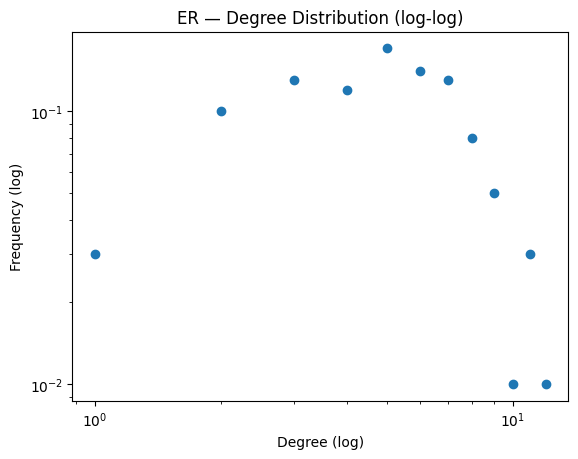

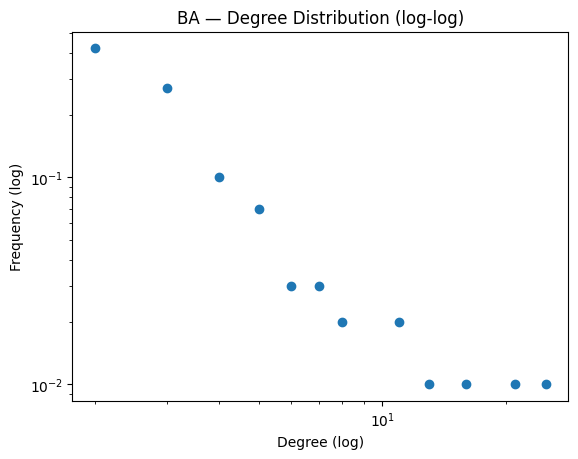

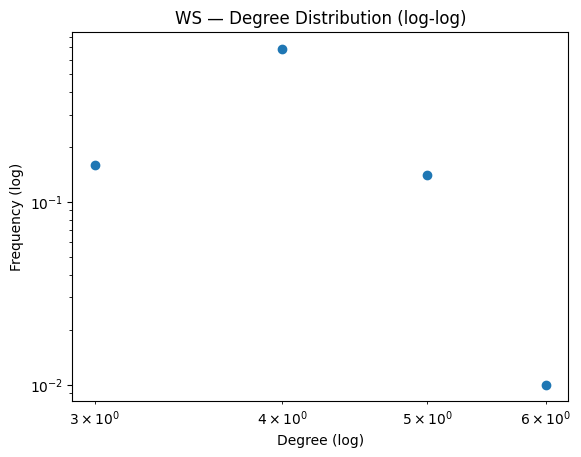

In [19]:
# Degree distributions
def degree_hist(G):
  degs = [d for _, d in G.degree()]
  vals, counts = np.unique(degs, return_counts=True)
  return vals, counts / counts.sum()


figures = []
for name, graph in [('ER', ER), ('BA', BA), ('WS', WS)]:
  vals, freq = degree_hist(graph)
  plt.figure()
  plt.scatter(vals, freq)
  plt.yscale('log')
  plt.xscale('log')
  plt.xlabel('Degree (log)')
  plt.ylabel('Frequency (log)')
  plt.title(f'{name} — Degree Distribution (log-log)')
  plt.show()

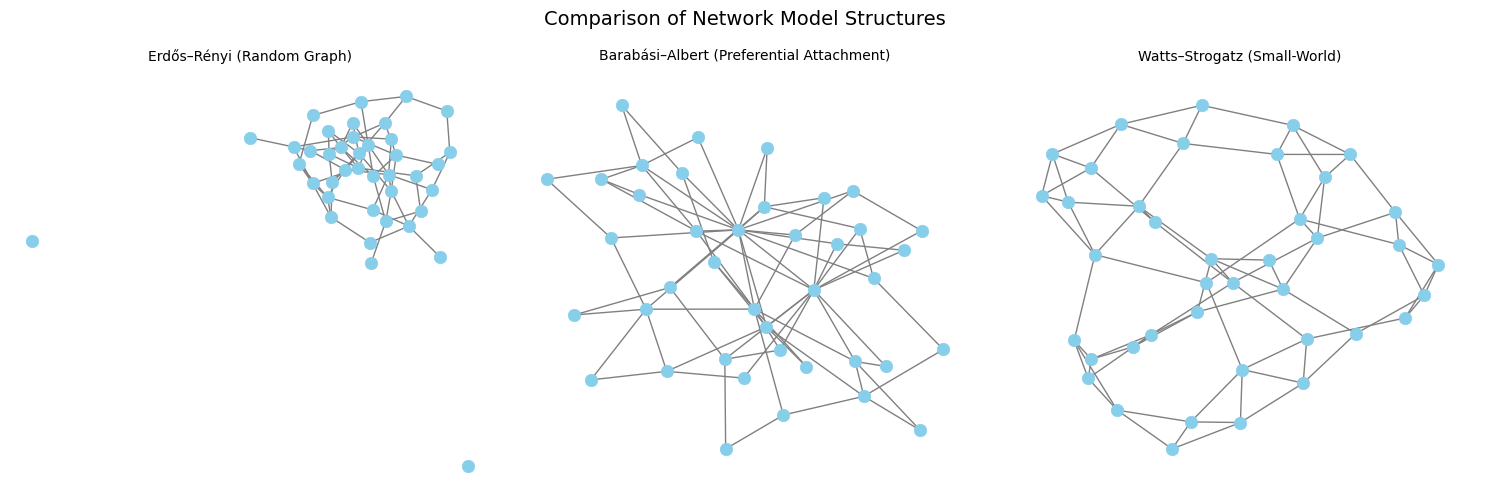

In [20]:
# Visualize the three models side by side
ER_viz, BA_viz, WS_viz = model_graphs(n=40, p=0.08, m_attach=2, k=4, beta=0.2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
graphs = [('Erdős–Rényi (Random Graph)', ER_viz),
          ('Barabási–Albert (Preferential Attachment)', BA_viz),
          ('Watts–Strogatz (Small-World)', WS_viz)]

for ax, (title, Gv) in zip(axes, graphs):
  pos = nx.spring_layout(Gv, seed=0)
  nx.draw(Gv, pos,
          node_size=80,
          node_color='skyblue',
          edge_color='gray',
          linewidths=0.5,
          with_labels=False,
          ax=ax)
  ax.set_title(title, fontsize=10)
  ax.axis('off')

plt.suptitle("Comparison of Network Model Structures", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## **Edge Formation Mechanisms & Link Prediction Heuristics**
We implement simple probability rules and heuristics:
- **Random Attachment**: constant probability
- **Preferential Attachment**: probability ∝ degree
- **Local Attachment**: common neighbors / Jaccard / Adamic–Adar
- **Homophily**: cosine similarity on node attributes


In [21]:
from itertools import combinations
from math import log


def candidate_pairs(G):
  # Undirected candidate pairs that are not currently connected
  Gu = G.to_undirected()
  pairs = []
  for u, v in combinations(Gu.nodes(), 2):
    if not Gu.has_edge(u, v):
      pairs.append((u, v))
  return pairs


def preferential_attachment_scores(G):
  Gu = G.to_undirected()
  deg = dict(Gu.degree())
  scores = {}
  for u, v in candidate_pairs(G):
    scores[(u, v)] = deg[u] * deg[v]
  return scores


def common_neighbors_scores(G):
  Gu = G.to_undirected()
  scores = {}
  for u, v in candidate_pairs(G):
    cn = len(list(nx.common_neighbors(Gu, u, v)))
    scores[(u, v)] = cn
  return scores


def jaccard_scores(G):
  Gu = G.to_undirected()
  scores = {}
  for u, v in candidate_pairs(G):
    n_u = set(Gu.neighbors(u))
    n_v = set(Gu.neighbors(v))
    inter = len(n_u & n_v)
    uni = len(n_u | n_v)
    scores[(u, v)] = inter / uni if uni > 0 else 0.0
  return scores


def adamic_adar_scores(G):
  Gu = G.to_undirected()
  scores = {}
  for u, v in candidate_pairs(G):
    cn = list(nx.common_neighbors(Gu, u, v))
    s = 0.0
    for w in cn:
      deg_w = Gu.degree(w)
      if deg_w > 1:
        s += 1.0 / log(deg_w)
    scores[(u, v)] = s
  return scores


def top_k(scores, k=5):
  return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]


# Demo on Karate graph
scores_pa = preferential_attachment_scores(K)
scores_cn = common_neighbors_scores(K)
scores_jc = jaccard_scores(K)
scores_aa = adamic_adar_scores(K)
pd.DataFrame({
    'PreferentialAttachment': dict(top_k(scores_pa, 10)),
    'CommonNeighbors': dict(top_k(scores_cn, 10)),
    'Jaccard': dict(top_k(scores_jc, 10)),
    'AdamicAdar': dict(top_k(scores_aa, 10))
})

PreferentialAttachment  CommonNeighbors  Jaccard  AdamicAdar
0  33                   272.0              4.0      NaN    2.711020
   32                   192.0              3.0      NaN    1.613740
2  33                   170.0              6.0      NaN    4.719381
1  33                   153.0              3.0      NaN    2.252922
   32                   108.0              NaN      NaN         NaN
3  33                   102.0              NaN      NaN         NaN
0  23                    80.0              NaN      NaN         NaN
3  32                    72.0              NaN      NaN         NaN
5  33                    68.0              NaN      NaN         NaN
6  33                    68.0              NaN      NaN         NaN
7  13                     NaN              4.0      NaN    1.808198
1  8                      NaN              3.0      NaN         NaN
2  30                     NaN              3.0      NaN         NaN
   31                     NaN              3.0      NaN    1.673343
4  5                      NaN              3.0      NaN    1.992261
6  10                     NaN              3.0      NaN    1.992261
14 15                     NaN              NaN      1.0         NaN
   18                     NaN              NaN      1.0         NaN
   20                     NaN              NaN      1.0         NaN
   22                     NaN              NaN      1.0         NaN
15 18                     NaN              NaN      1.0         NaN
   20                     NaN              NaN      1.0         NaN
   22                     NaN              NaN      1.0         NaN
17 21                     NaN              NaN      1.0         NaN
18 20                     NaN              NaN      1.0         NaN
   22                     NaN              NaN      1.0         NaN
23 31                     NaN              NaN      NaN    1.665625
   24                     NaN              NaN      NaN    1.631587

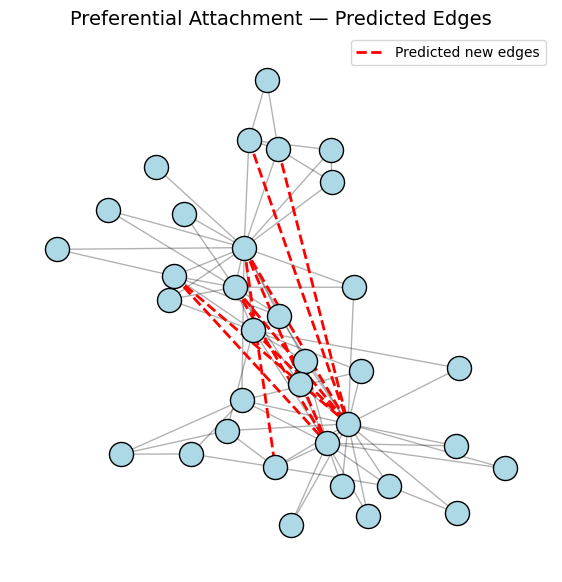

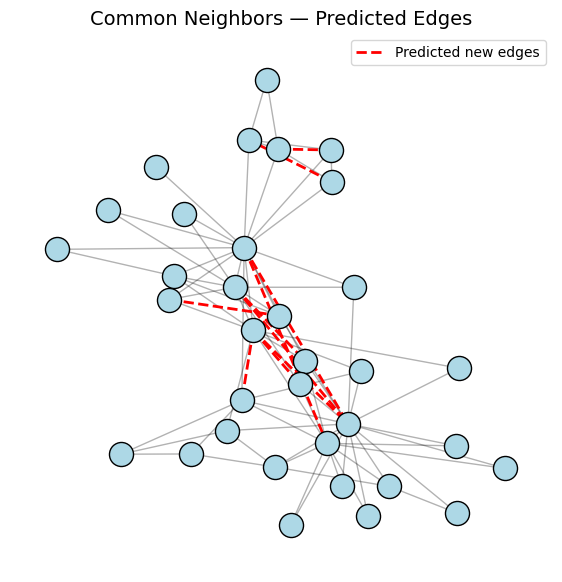

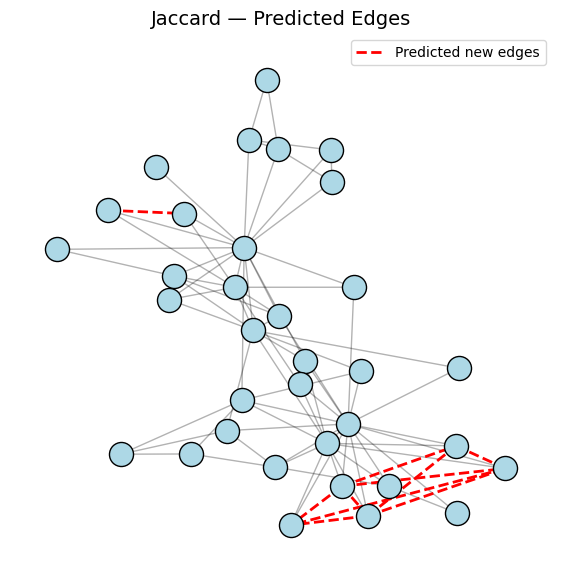

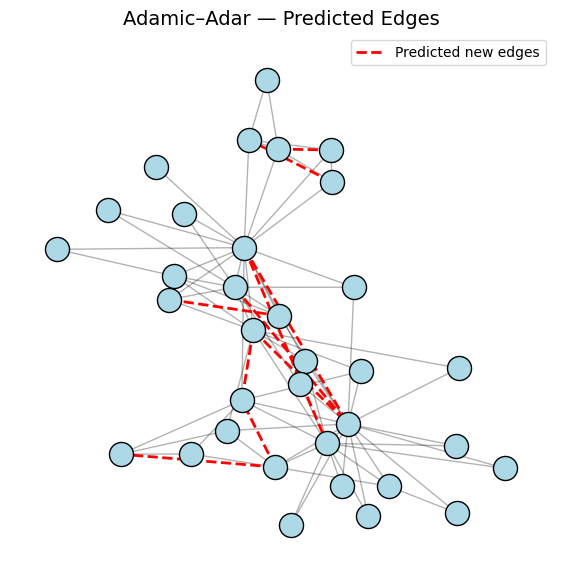

In [22]:
def visualize_predicted_edges(G, score_dict, top_k=10, title="Predicted Edges"):
  """
  Visualize the top predicted new edges for a given scoring rule.

  Parameters:
      G (networkx.Graph): Base graph
      score_dict (dict): {(u,v): score} mapping
      top_k (int): number of top edges to highlight
      title (str): plot title
  """
  Gu = G.to_undirected()
  pos = nx.spring_layout(Gu, seed=0)

  # Take top k predicted edges
  top_edges = [pair for pair, _ in sorted(score_dict.items(), key=lambda x: x[1], reverse=True)[:top_k]]

  # Draw base network (existing edges)
  plt.figure(figsize=(7, 7))
  nx.draw_networkx_nodes(Gu, pos, node_size=300, node_color="lightblue", edgecolors="black")
  nx.draw_networkx_edges(Gu, pos, alpha=0.3)

  # Overlay predicted edges in red
  nx.draw_networkx_edges(Gu, pos, edgelist=top_edges, edge_color="red",
                         width=2.0, style="dashed", label="Predicted new edges")

  plt.title(title, fontsize=14)
  plt.legend()
  plt.axis("off")
  plt.show()


# --- Example visualizations on the Karate Club graph ---
visualize_predicted_edges(K, scores_pa, top_k=10, title="Preferential Attachment — Predicted Edges")
visualize_predicted_edges(K, scores_cn, top_k=10, title="Common Neighbors — Predicted Edges")
visualize_predicted_edges(K, scores_jc, top_k=10, title="Jaccard — Predicted Edges")
visualize_predicted_edges(K, scores_aa, top_k=10, title="Adamic–Adar — Predicted Edges")

## **Homophily (Attribute Similarity)**
We simulate numeric attributes and use cosine similarity as a proxy for homophily.

In [23]:
def random_attributes(G, d=4):
  X = {n: np.random.randn(d) for n in G.nodes()}
  return X


def cosine_similarity(u, v):
  num = np.dot(u, v)
  den = (np.linalg.norm(u) * np.linalg.norm(v))
  return float(num / den) if den > 0 else 0.0


def homophily_scores(G, X):
  scores = {}
  for u, v in candidate_pairs(G):
    scores[(u, v)] = cosine_similarity(X[u], X[v])
  return scores


XK = random_attributes(K)
scores_h = homophily_scores(K, XK)
pd.Series(dict(top_k(scores_h, 10)))

27  32    0.958663
3   9     0.947123
4   15    0.919863
20  26    0.912968
4   23    0.896922
2   4     0.892641
7   33    0.888613
15  23    0.887981
10  24    0.881361
1   26    0.879961
dtype: float64

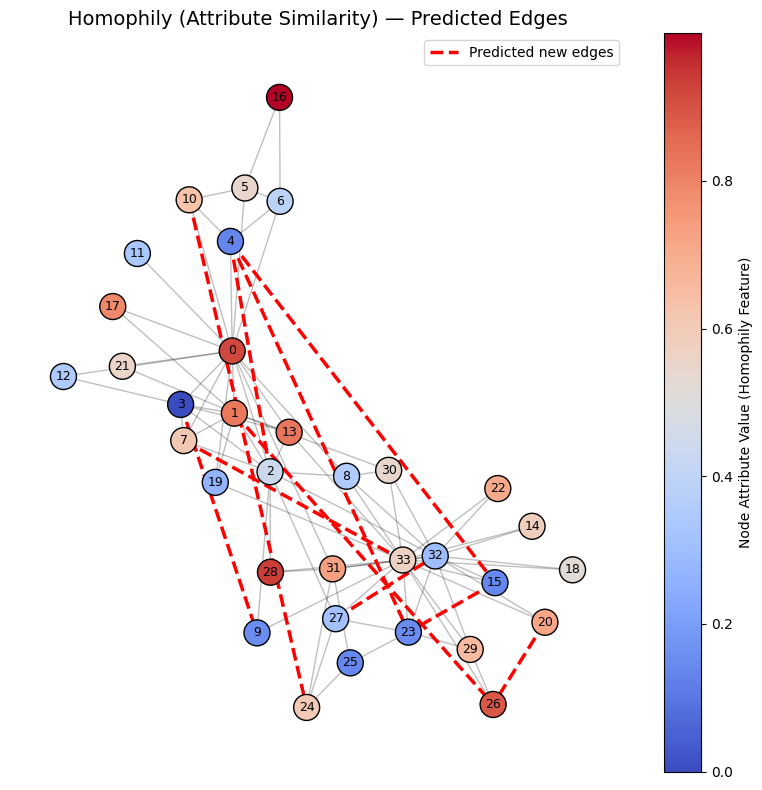

In [24]:
def visualize_homophily(G, X, scores_h, top_k=10, title="Homophily (Attribute Similarity) — Predicted Edges"):
  """
  Visualize nodes colored by attribute values and top predicted edges by similarity.
  """
  Gu = G.to_undirected()
  pos = nx.spring_layout(Gu, seed=1)

  # Reduce attributes to scalar color values (mean embedding dimension)
  attr_scalar = {n: np.mean(X[n]) for n in Gu.nodes()}
  node_colors = np.array([attr_scalar[n] for n in Gu.nodes()])

  # Normalize colors to 0–1 for consistent colormap scaling
  norm = (node_colors - node_colors.min()) / (node_colors.max() - node_colors.min() + 1e-9)

  # Select top-K predicted edges
  top_edges = [pair for pair, _ in sorted(scores_h.items(), key=lambda x: x[1], reverse=True)[:top_k]]

  plt.figure(figsize=(8, 8))
  nodes = nx.draw_networkx_nodes(
      Gu, pos,
      node_size=350,
      node_color=norm,
      cmap=plt.cm.coolwarm,
      edgecolors="black"
  )
  nx.draw_networkx_edges(Gu, pos, alpha=0.25)
  nx.draw_networkx_edges(
      Gu, pos, edgelist=top_edges,
      edge_color="red",
      width=2.5,
      style="dashed",
      label="Predicted new edges"
  )
  nx.draw_networkx_labels(Gu, pos, font_size=9, font_color="black")

  plt.colorbar(nodes, label="Node Attribute Value (Homophily Feature)")
  plt.title(title, fontsize=14)
  plt.legend()
  plt.axis("off")
  plt.tight_layout()
  plt.show()


visualize_homophily(K, XK, scores_h, top_k=10)

# **Diffusion (SIR) Simulation**
We implement a simple discrete-time SIR model and compare diffusion on ER, BA, and WS graphs.

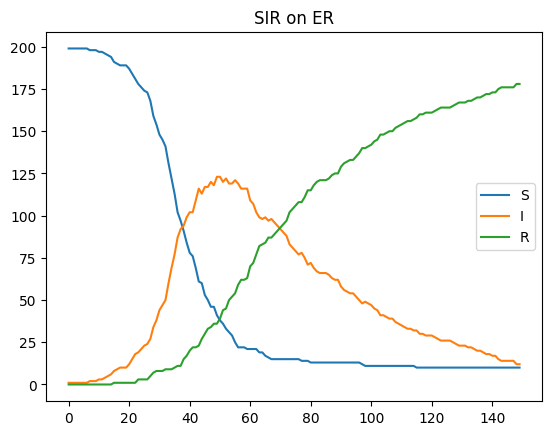

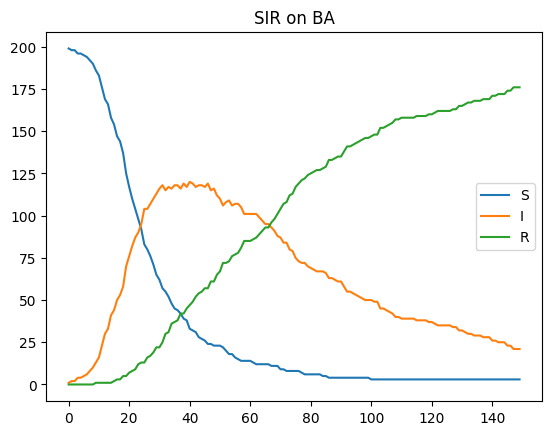

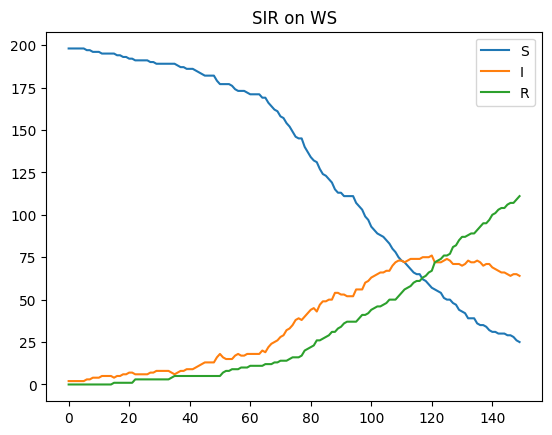

In [25]:
def sir_simulation(G, beta=0.05, gamma=0.02, steps=100, seed_node=None):
  Gu = G.copy()
  nodes = list(Gu.nodes())
  if seed_node is None:
    seed_node = np.random.choice(nodes)
  state = {n: 'S' for n in nodes}
  state[seed_node] = 'I'
  S_hist, I_hist, R_hist = [], [], []
  for t in range(steps):
    new_state = state.copy()
    for n in nodes:
      if state[n] == 'I':
        # infect neighbors
        for nb in Gu.neighbors(n):
          if state[nb] == 'S' and np.random.rand() < beta:
            new_state[nb] = 'I'
        # recover
        if np.random.rand() < gamma:
          new_state[n] = 'R'
    state = new_state
    S_hist.append(sum(1 for v in state.values() if v == 'S'))
    I_hist.append(sum(1 for v in state.values() if v == 'I'))
    R_hist.append(sum(1 for v in state.values() if v == 'R'))
  return np.array(S_hist), np.array(I_hist), np.array(R_hist)


def compare_sir(n=200):
  ER, BA, WS = model_graphs(n=n, p=0.02, m_attach=2, k=4, beta=0.1)
  graphs = {'ER': ER, 'BA': BA, 'WS': WS}
  results = {}
  for name, g in graphs.items():
    S, I, R = sir_simulation(g, beta=0.05, gamma=0.02, steps=150)
    results[name] = (S, I, R)
  return results


results = compare_sir(n=200)
for name, (S, I, R) in results.items():
  plt.figure()
  plt.plot(S, label='S')
  plt.plot(I, label='I')
  plt.plot(R, label='R')
  plt.title(f'SIR on {name}')
  plt.legend()
  plt.show()

## **Temporal SNA**
Create a simple temporal network (edges appear over time) and track clustering & average degree.

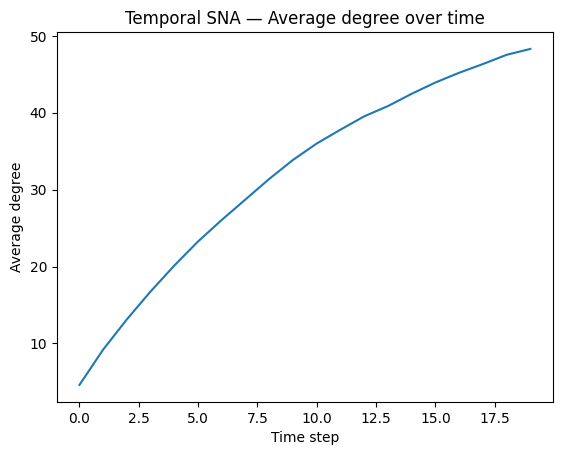

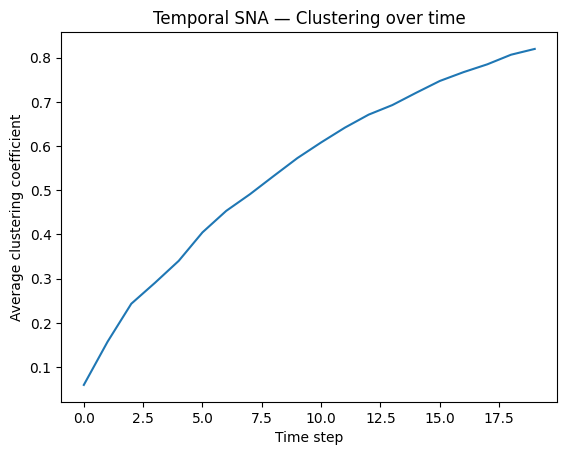

In [26]:
def temporal_graph(n=60, T=20, prob_new_edge=0.08, seed=1):
  rng = np.random.default_rng(seed)
  base = nx.Graph()
  base.add_nodes_from(range(n))
  snapshots = []
  for t in range(T):
    Gu = base.copy()
    # randomly add some edges at each timestep
    for u in range(n):
      for v in range(u + 1, n):
        if not Gu.has_edge(u, v) and rng.random() < prob_new_edge:
          Gu.add_edge(u, v)
    snapshots.append(Gu)
    base = Gu
  return snapshots


snaps = temporal_graph()
ts = list(range(len(snaps)))
avg_deg = [np.mean([d for _, d in Gt.degree()]) for Gt in snaps]
avg_cc = [nx.average_clustering(Gt) if Gt.number_of_edges() > 0 else 0.0 for Gt in snaps]

plt.figure()
plt.plot(ts, avg_deg)
plt.xlabel('Time step')
plt.ylabel('Average degree')
plt.title('Temporal SNA — Average degree over time')
plt.show()

plt.figure()
plt.plot(ts, avg_cc)
plt.xlabel('Time step')
plt.ylabel('Average clustering coefficient')
plt.title('Temporal SNA — Clustering over time')
plt.show()

## **Task**

1. Generate the doc2matrix to plug into the SNA Jupyter notebook.
2. Execute the remaining parts of the notebook.

**Expected**
- Executed Jupyter notebook that has clear output.

**Pipeline**
1. Create a doc2matrix.
> Similar to previous activity, we can utilize `TfidVectorizer` for doc2matrix
2. Define graph nodes and edges.
> Defining nodes and edges that the graph will work with. The input data is limited to columns with respect to comments (as such, `comment`, `comment_author`, `comment_score` are kept). `Nodes` are going to use `comment`, while `Edges` will use similarity between comments (with the help of doc2matrix and cosine similarity based on a standard threshold `0.5`).
3. Create the `Networkx` graph.
> Use the defined nodes and edges, and show the number of nodes and edges. Will plot in the later stages.
4. Graph visualizations.

**doc2matrix**

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words=combined_stopwords,
    max_features=1000,
    lowercase=True,
)

tfidf_matrix = vectorizer.fit_transform(comments_df['comment'].astype(str))
feature_names = vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("First 10 feature names:", feature_names[:50])


f:\_GitHub\CSCI161-SocialComputing\venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ain', 'daren', 'hadn', 'herse', 'himse', 'itse', 'mayn', 'mightn', 'mon', 'mustn', 'myse', 'needn', 'oughtn', 'shan'] not in stop_words.
  warnings.warn(


TF-IDF matrix shape: (12552, 1000)
First 10 feature names: ['000' '100' '11' '12' '15' '1987' '1iebyap' '1rdcnibobw' '1st' '20'
 '2016' '2022' '20k' '25' '2nd' '30' '40' '4ps' '50' '60' 'accept'
 'access' 'account' 'accountancy' 'action' 'actual' 'add' 'admin'
 'administration' 'advantage' 'afford' 'agad' 'age' 'agencies' 'agency'
 'agrarian' 'agree' 'agri' 'agricultural' 'agriculture' 'akala' 'akong'
 'alam' 'anak' 'animal' 'animals' 'anong' 'answer' 'anti' 'apply']


**Defining Nodes and Edges**

In [28]:
num_comments = tfidf_matrix.shape[0]
comment_nodes = [f'comment_{i}' for i in range(num_comments)]
print(f"Number of comments: {num_comments}")
print(f"First 5 node labels: {comment_nodes[:10]}")

Number of comments: 12552
First 5 node labels: ['comment_0', 'comment_1', 'comment_2', 'comment_3', 'comment_4', 'comment_5', 'comment_6', 'comment_7', 'comment_8', 'comment_9']


In [29]:
cosine_sim_matrix = linear_kernel(tfidf_matrix, tfidf_matrix)

thresholds = [0.1, 0.5, 0.9]
edges_by_threshold = {}

# For Reference only
for threshold in thresholds:
    comment_edges = []
    for i in range(num_comments):
        for j in range(i + 1, num_comments):
            if cosine_sim_matrix[i, j] > threshold:
                comment_edges.append((comment_nodes[i], comment_nodes[j]))
    edges_by_threshold[threshold] = comment_edges
    print(f"Threshold {threshold}: {len(comment_edges)} edges")

Threshold 0.1: 2806090 edges
Threshold 0.5: 60374 edges
Threshold 0.9: 6580 edges


> At this stage, cosine similarity is calculated at 3 different thresholds to test how deep the data is related. In this case, at a **low threshold (much more noisy output) is about 2.8 million edges**, while a **higher threshold yields a 6.5 thousand edges only.**

**Networkx Graph**

In [30]:
# Choose the threshold you want
final_threshold = 0.5
comment_edges = edges_by_threshold[final_threshold]  # explicitly pick 0.5 edges

G_comments = nx.Graph()
G_comments.add_nodes_from(comment_nodes)
G_comments.add_edges_from(comment_edges)

print(f"Number of nodes: {G_comments.number_of_nodes()}")
print(f"Number of edges: {G_comments.number_of_edges()}")


Number of nodes: 12552
Number of edges: 60374


**Networkx Visualization, Analysis, and Thoughts**

Number of nodes: 12552
Number of edges: 60374
Density: 0.0008


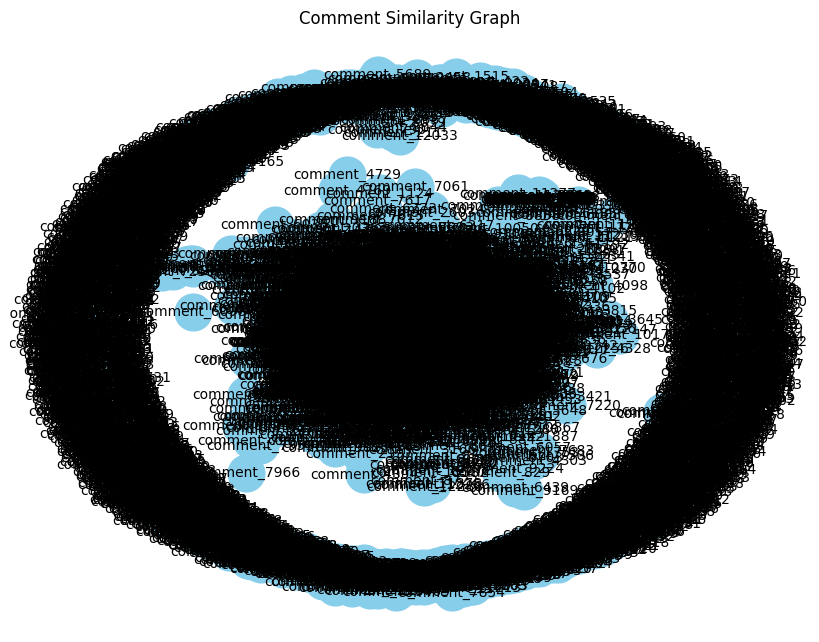

In [31]:
n_nodes = G_comments.number_of_nodes()
n_edges = G_comments.number_of_edges()
density = nx.density(G_comments)

print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Density: {density:.4f}")

# Commented out to stop printing long cosine sim.
# deg_cent = nx.degree_centrality(G_comments)
# print("\nDegree Centrality:")
# for node, centrality in deg_cent.items():
#     print(f"  {node}: {centrality:.4f}")

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_comments)  # Use spring layout for visualization
nx.draw(G_comments, pos, with_labels=True, node_size=700, node_color='skyblue', font_size=10, edge_color='gray')
plt.title('Comment Similarity Graph')
plt.show()

Based on the cosine similarity and the networkx graph plots, it is evident that the data may prove to be too noisy. This is probably because of the threshold used (0.5) which makes the edges and nodes and edges connect even with a very low similarity. To test this, I increased the threshold to 0.9 to see how the network changes.

In [32]:
final_threshold = 0.9 # CHANGED TO A HIGHER THRESHOLD TO SEE THE DIFFERENCE.
comment_edges = edges_by_threshold[final_threshold] 

G_comments = nx.Graph()
G_comments.add_nodes_from(comment_nodes)
G_comments.add_edges_from(comment_edges)

print(f"Number of nodes: {G_comments.number_of_nodes()}")
print(f"Number of edges: {G_comments.number_of_edges()}")


Number of nodes: 12552
Number of edges: 6580


Number of nodes: 12552
Number of edges: 6580
Density: 0.0001


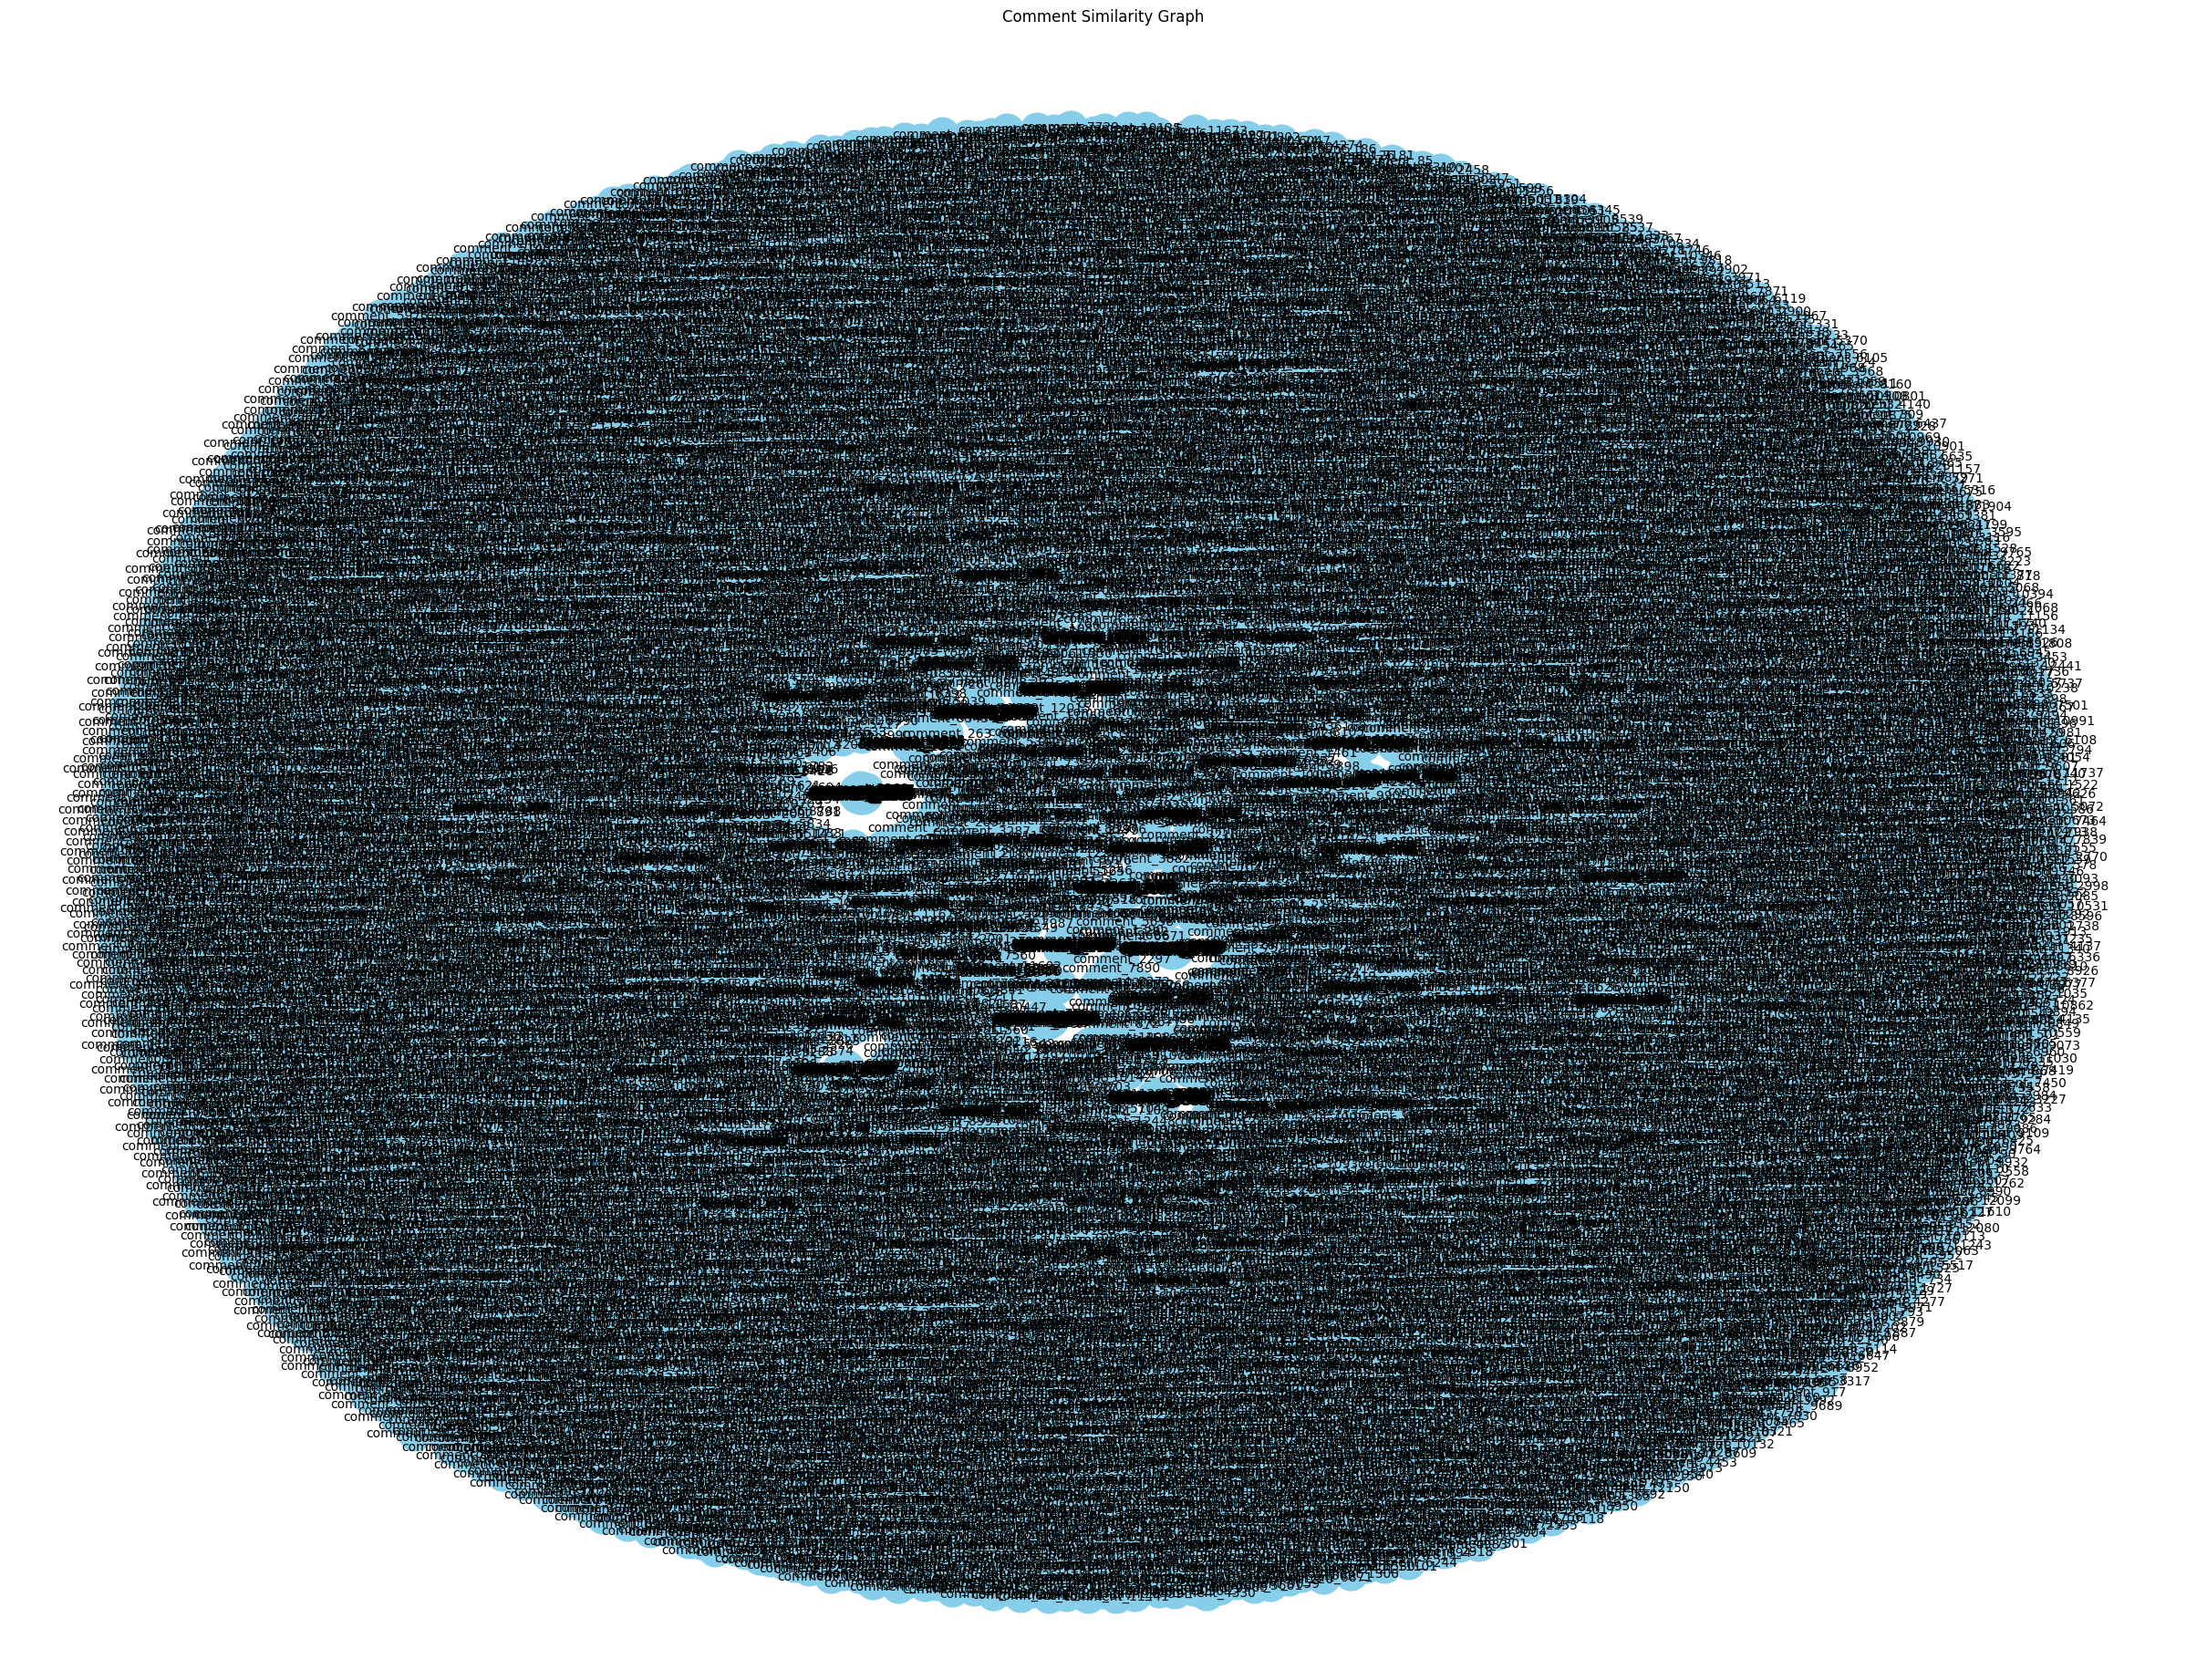

In [34]:
n_nodes = G_comments.number_of_nodes()
n_edges = G_comments.number_of_edges()
density = nx.density(G_comments)

print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Density: {density:.4f}")

# Commented out to stop printing long cosine sim.
# deg_cent = nx.degree_centrality(G_comments)
# print("\nDegree Centrality:")
# for node, centrality in deg_cent.items():
#     print(f"  {node}: {centrality:.4f}")

plt.figure(figsize=(24, 18))
pos = nx.spring_layout(G_comments)  # Use spring layout for visualization
nx.draw(G_comments, pos, with_labels=True, node_size=700, node_color='skyblue', font_size=10, edge_color='gray')
plt.title('Comment Similarity Graph')
plt.show()

***Final Thoughts / Analysis on the SNA Pipeline***

The network graph utilized a `higher similarity threshold`, which resulted in a clearer and more interpretable structure. While this led to significantly fewer connections compared to the `lower-threshold graph`, this trade-off is acceptable since the remaining links represent stronger and more meaningful similarities between comments.

> While it is hard to see/view the actual network graph because it shows heavy cluttering, the `0.5 Threshold` shows a `density of 0.0008` proving that there are more connections between the nodes and edges compared to the `0.9 Threshold` that curated a `density of 0.0001` which provides us with an even sparser network.

However, the reduced connectivity might also indicate that the **dataset lacks depth or contextual richness in its conversations**. Many comments appear to be short or incomplete, often relying heavily on external context to make sense (e.g., *“What does this mean for the Philippines?”*). When processed in isolation, such comments may not register as semantically related to more descriptive statements like *“The agricultural situation in the Philippines is not improving.”* As a result, cosine similarity struggles to capture their connection, since it evaluates only textual overlap and not broader conversational relevance.

> More so that there are rows that are simply troll-like comments or bashing comments that say `F*&* the government` or `P-word ng mga <insert government official>` which can be deemed not-similar or whatnot.

This suggests that **cosine similarity may perform better with more structured and context-rich datasets**—such as those containing full discussion threads, detailed posts, or labelled topic segments—rather than brief, context-dependent comments.

***Side Thought***

An alternative approach could involve using `post_body` or `post_title` as anchor texts and then mapping the `comments` that are most similar to each post. This would allow for the creation of a network graph showing how comments relate to their parent post rather than to one another. However, this approach would **require dense and content-rich subreddit data**, which may be uncommon in **domains like agriculture** in `r/Philippines`, where discussions tend to be shorter or less interactive.